
### Deep Learning — Complex Computing Problem

In [ ]:
# Install all required libraries for this notebook
# transformers: HuggingFace library for ClinicalBERT
# bertviz: attention visualization for Transformer models
# imbalanced-learn: SMOTE for handling class imbalance (critical in medical datasets)
!pip install transformers bertviz imbalanced-learn datasets -q
!pip install torch torchvision torchaudio -q  # PyTorch (already on Colab, this ensures latest)
print("All libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.9 MB/s eta 0:00:00
✅ All libraries installed.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
import os
import random
warnings.filterwarnings('ignore')

# Reproducibility — fix all random seeds so results are consistent across runs
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# TensorFlow / Keras — for DNN, LSTM, GRU, Bi-LSTM
import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, LSTM, GRU,
    Bidirectional, Input, Embedding
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# PyTorch — for ClinicalBERT fine-tuning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
torch.manual_seed(SEED)

# HuggingFace Transformers
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Imbalanced data handling
from imblearn.over_sampling import SMOTE

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available (PyTorch): {torch.cuda.is_available()}")
print(f"GPU available (TensorFlow): {len(tf.config.list_physical_devices('GPU')) > 0}")

# Set device for PyTorch operations
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

TensorFlow version: 2.20.0
PyTorch version: 2.10.0+cu128
GPU available (PyTorch): True
GPU available (TensorFlow): True
Using device: cuda


---
## Dowloading DataSet & Loading it
We use the **PhysioNet Sepsis Prediction Challenge 2019** dataset.
Each patient has hourly vitals (time-series) and a SepsisLabel column (binary: 0 = stable, 1 = sepsis).

In [ ]:
import glob
import os
import zipfile
import pandas as pd



# Ensure kaggle.json is in the right place
kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')
if not os.path.exists(kaggle_json_path):
    # Check if kaggle.json is in the current working directory
    if os.path.exists('kaggle.json'):
        os.makedirs(os.path.dirname(kaggle_json_path), exist_ok=True)
        !mv kaggle.json ~/.kaggle/kaggle.json
        !chmod 600 ~/.kaggle/kaggle.json
        print("✅ kaggle.json moved to ~/.kaggle/ and permissions set.")
    else:
        raise FileNotFoundError(
            "kaggle.json not found. Please upload it to your Colab session "
            "or the current directory to download the dataset."
        )

# Install Kaggle API if not already installed
try:
    import kaggle
except ImportError:
    !pip install kaggle -q
    import kaggle

dataset_name = 'salikhussaini49/prediction-of-sepsis'
print(f"Attempting to download dataset: {dataset_name}")

# Check if the 'Dataset.csv' already exists
if not os.path.exists('Dataset.csv'):
    !kaggle datasets download -d {dataset_name} --force
    print("✅ Dataset downloaded.")

    # Unzip the dataset
    zip_file_path = f"{dataset_name.split('/')[-1]}.zip"
    if os.path.exists(zip_file_path):
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("✅ Dataset unzipped.")
        os.remove(zip_file_path) # Clean up the zip file
    else:
        print(f"⚠️ Warning: Zip file '{zip_file_path}' not found after download.")
else:
    print("✅ Dataset already present. Skipping download and unzip.")


# Try to load real dataset; fall back to synthetic
try:
    all_found_files = glob.glob('training/*.psv') + glob.glob('*.csv') # Check for both types

    if not all_found_files:
        raise FileNotFoundError("No .psv or .csv dataset files found after download.")

    all_patient_data = []
    num_psv_patients = 0
    num_csv_files = 0

    # Iterate through found files and load them based on extension
    for f in all_found_files:
        if f.endswith('.psv'):
            patient_df = pd.read_csv(f, sep='|')
            patient_id = os.path.basename(f).replace('.psv', '')
            patient_df['Patient_ID'] = patient_id
            all_patient_data.append(patient_df)
            num_psv_patients += 1
        elif f.endswith('.csv'):
            # Load CSVs. Assuming 'Dataset.csv' is the main one and contains all data.
            # We'll prioritize the first CSV found, if multiple exist.
            if num_csv_files == 0: # Only process the first CSV found
                csv_df = pd.read_csv(f, sep=',', encoding='utf-8')
                # Remove potential 'Unnamed: 0' column if the first column was empty in CSV
                if csv_df.columns[0].startswith('Unnamed:'):
                    csv_df = csv_df.drop(columns=csv_df.columns[0])
                all_patient_data.append(csv_df)
            num_csv_files += 1

    if all_patient_data:

        df_raw = pd.concat(all_patient_data, ignore_index=True)
        print(f"✅ Loaded real dataset: {num_psv_patients} patients from .psv files and {num_csv_files} .csv files. Raw shape: {df_raw.shape}")
    else:
        raise FileNotFoundError("No valid .psv or .csv dataset files were processed.")

except Exception as e:
    print(f"Real dataset not found or could not be processed ({e}). Using synthetic dataset.")
    # Ensure numpy is imported for synthetic dataset generation
    import numpy as np
    df_raw = generate_synthetic_dataset(n_patients=2000, timesteps=24)

# Display basic info to confirm loading
if df_raw is not None:
    print(f"\nRaw data info:")
    print(df_raw.head())
    print(df_raw.info())

Attempting to download dataset: salikhussaini49/prediction-of-sepsis
✅ Dataset already present. Skipping download and unzip.
✅ Loaded real dataset: 0 patients from .psv files and 1 .csv files. Raw shape: (1552210, 43)

Raw data info:
   Hour    HR  O2Sat  Temp    SBP   MAP   DBP  Resp  EtCO2  BaseExcess  ...  \
0     0   NaN    NaN   NaN    NaN   NaN   NaN   NaN    NaN         NaN  ...   
1     1  65.0  100.0   NaN    NaN  72.0   NaN  16.5    NaN         NaN  ...   
2     2  78.0  100.0   NaN    NaN  42.5   NaN   NaN    NaN         NaN  ...   
3     3  73.0  100.0   NaN    NaN   NaN   NaN  17.0    NaN         NaN  ...   
4     4  70.0  100.0   NaN  129.0  74.0  69.0  14.0    NaN         NaN  ...   

   Fibrinogen  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  \
0         NaN        NaN  68.54       0    NaN    NaN        -0.02       1   
1         NaN        NaN  68.54       0    NaN    NaN        -0.02       2   
2         NaN        NaN  68.54       0    NaN    NaN    

---
## Exploratory Data Analysis EDA

DATASET OVERVIEW
Shape: (1552210, 43)

Class Distribution:
SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64

Missing Values (%):
Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
dtype: float64


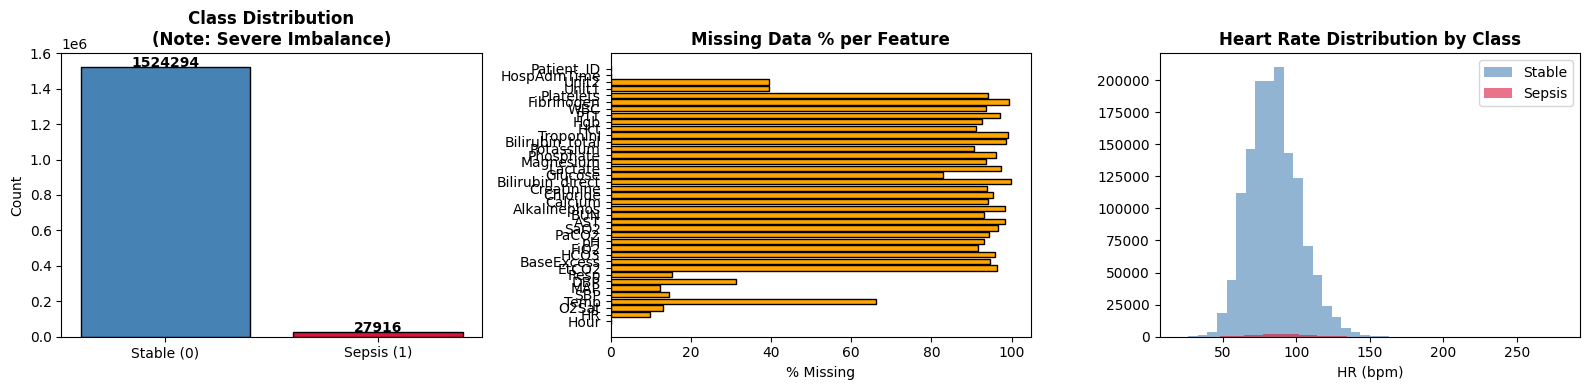

✅ EDA plots saved.


In [ ]:

# EXPLORATORY DATA ANALYSIS

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df_raw.shape}")
print(f"\nClass Distribution:")
print(df_raw['SepsisLabel'].value_counts())
print(f"\nMissing Values (%):\n{(df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False).head(10)}")

# Visualize class imbalance — critical to understand before modeling
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Class distribution
class_counts = df_raw['SepsisLabel'].value_counts()
axes[0].bar(['Stable (0)', 'Sepsis (1)'], class_counts.values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution\n(Note: Severe Imbalance)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 2: Missing data heatmap (sample)
vital_cols = [c for c in df_raw.columns if c not in ['patient_id', 'hour', 'SepsisLabel', 'Gender', 'Age', 'ICULOS']]
missing_pct = df_raw[vital_cols].isnull().mean() * 100
axes[1].barh(missing_pct.index, missing_pct.values, color='orange', edgecolor='black')
axes[1].set_title('Missing Data % per Feature', fontweight='bold')
axes[1].set_xlabel('% Missing')

# Plot 3: Heart rate distribution by class
stable = df_raw[df_raw['SepsisLabel'] == 0]['HR'].dropna()
sepsis = df_raw[df_raw['SepsisLabel'] == 1]['HR'].dropna()
axes[2].hist(stable, bins=40, alpha=0.6, label='Stable', color='steelblue')
axes[2].hist(sepsis, bins=40, alpha=0.6, label='Sepsis', color='crimson')
axes[2].set_title('Heart Rate Distribution by Class', fontweight='bold')
axes[2].set_xlabel('HR (bpm)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA plots saved.")

---
##  Data Preprocessing
Clinical data is inherently messy — missing vitals, skewed distributions, mixed types.
We handle all of this systematically before model training.

In [ ]:

# Define feature columns (vital signs + lab values + demographics)
FEATURE_COLS = [c for c in df_raw.columns
                if c not in ['patient_id', 'hour', 'SepsisLabel']]
TARGET_COL = 'SepsisLabel'

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# Step 1: Imputation — fill missing vitals with column median
# here i will use median imputation rather than mean bcuase extreme values may skew the mean.
imputer = SimpleImputer(strategy='median')
X = df_raw[FEATURE_COLS].copy()
y = df_raw[TARGET_COL].values

X_imputed = imputer.fit_transform(X)
print(f"\nAfter imputation — missing values: {np.isnan(X_imputed).sum()}")

# Step 2: Normalization — scale all features to zero mean, unit variance
# Critical for gradient-based optimization: unnormalized features cause
# the loss landscape to be elongated, making training slow and unstable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Step 3: Train / Validation / Test split — 70% / 15% / 15%
# We stratify to preserve class ratios in each split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nSplit sizes:")
print(f"  Train: {X_train.shape} | Sepsis rate: {y_train.mean()*100:.1f}%")
print(f"  Val:   {X_val.shape}   | Sepsis rate: {y_val.mean()*100:.1f}%")
print(f"  Test:  {X_test.shape}  | Sepsis rate: {y_test.mean()*100:.1f}%")

# Step 4: Handle class imbalance with SMOTE (Synthetic Minority Over-sampling)

# As we know sepsis are rare ~10% in this dataset. so we will use smote to balance the classes in the training set.
smote = SMOTE(random_state=SEED)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Train: {X_train_balanced.shape} | Sepsis rate: {y_train_balanced.mean()*100:.1f}%")
print("✅ Preprocessing complete.")

Features (42): ['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'Patient_ID']

After imputation — missing values: 0

Split sizes:
  Train: (1086547, 42) | Sepsis rate: 1.8%
  Val:   (232831, 42)   | Sepsis rate: 1.8%
  Test:  (232832, 42)  | Sepsis rate: 1.8%

After SMOTE:
  Train: (2134012, 42) | Sepsis rate: 50.0%
✅ Preprocessing complete.


---
## Evaluation Utilities
We define reusable functions for computing and plotting metrics.

> **Why Recall matters most here**: A false negative (missed sepsis case) can cost a patient's life. A false positive (flagging a stable patient) wastes a nurse's time — annoying, but recoverable. In high-stakes medical AI, we optimize for Recall even at the cost of Precision.

In [ ]:
# Global results dictionary to collect metrics from all 6 models
RESULTS = {}

def evaluate_model(model_name, y_true, y_pred, training_time_sec):
    """
    Compute and store all required classification metrics.
    Returns a dict of metrics.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    metrics = {
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'Training Time (s)': round(training_time_sec, 1)
    }
    RESULTS[model_name] = metrics

    print(f"\n{'='*50}")
    print(f"  Results for: {model_name}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        print(f"  {k:<25}: {v}")

    # Per-class report
    print(f"\n  Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Stable', 'Sepsis']))

    # NOTE on Recall:
    # In this clinical context, Recall (sensitivity) for the Sepsis class is paramount.
    # A Recall of 0.85 means we catch 85% of true sepsis cases.
    # The remaining 15% are false negatives — patients who deteriorate without a warning.
    # This is far more dangerous than a false positive, which simply triggers
    # an unnecessary clinical check.
    print(f"  ⚕️  Sepsis Recall = {rec:.4f} "
          f"({'✅ Good' if rec >= 0.75 else '⚠️ Low — may miss sepsis cases'})")
    return metrics


def plot_confusion_matrix(y_true, y_pred, model_name, ax):
    """
    Plot a normalized confusion matrix on the given matplotlib axis.
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # row-normalize
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=['Stable', 'Sepsis'],
                yticklabels=['Stable', 'Sepsis'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'{model_name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')


def plot_training_curves(histories, labels, title='Training vs Validation Loss'):
    """
    Plot loss curves for one or more Keras training histories side by side.
    histories: list of Keras History objects
    labels: list of model names
    """
    n = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, hist, label in zip(axes, histories, labels):
        ax.plot(hist.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
        ax.plot(hist.history['val_loss'], label='Val Loss', color='darkorange',
                linewidth=2, linestyle='--')
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Store predictions for final confusion matrix grid
ALL_PREDS = {}
print("✅ Evaluation utilities defined.")

✅ Evaluation utilities defined.



#  GENERATION 1 — Deep Neural Network Baseline
### "Before we trust AI with patient lives, we need to know what a simple model can and cannot do."

We build a feedforward DNN on the tabular vital-sign features.
This establishes a performance floor that all subsequent models must beat.

In [ ]:
# ─────────────────────────────────────────────
# BUILD DNN ARCHITECTURE
# ─────────────────────────────────────────────

def build_dnn(input_dim, dropout_rate=0.3, use_batchnorm=True, optimizer='adam'):
    """
    Builds a deep feedforward network for binary clinical risk prediction.

    Architecture rationale:
    - 3 hidden layers (256 → 128 → 64): enough capacity to learn non-linear
      interactions between vitals (e.g., high HR + low BP = shock pattern)
    - ReLU activations: avoids the vanishing gradient problem that plagues
      sigmoid/tanh in deep networks; gradients remain non-zero for positive inputs
    - BatchNormalization: normalizes layer inputs, stabilizes training, and
      acts as a mild regularizer by adding noise via mini-batch statistics
    - Dropout: randomly zeros p% of neurons per forward pass, preventing
      co-adaptation and forcing the network to learn redundant representations
    - Sigmoid output: outputs a probability score [0, 1] for sepsis risk
    """
    model = Sequential([
        Input(shape=(input_dim,)),

        # --- Layer 1 ---
        Dense(256, activation='relu'),
        BatchNormalization() if use_batchnorm else Dropout(0),  # BN after activation
        Dropout(dropout_rate),

        # --- Layer 2 ---
        Dense(128, activation='relu'),
        BatchNormalization() if use_batchnorm else Dropout(0),
        Dropout(dropout_rate),

        # --- Layer 3 ---
        Dense(64, activation='relu'),
        Dropout(dropout_rate / 2),  # lighter dropout near output

        # Output: single sigmoid neuron = P(sepsis)
        Dense(1, activation='sigmoid')
    ])

    # Loss: binary cross-entropy is appropriate for binary classification
    # It measures the divergence between predicted probability and true label
    # Note: Loss function = error on a single sample
    #       Cost function  = average loss over the entire training batch
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


INPUT_DIM = X_train_balanced.shape[1]
print(f"Input dimensionality: {INPUT_DIM} features")

# Callbacks to prevent overfitting and reduce LR on plateaus
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

# Preview model architecture
model_preview = build_dnn(INPUT_DIM)
model_preview.summary()

Input dimensionality: 42 features


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,761 (210.00 KB)

 Trainable params: 52,993 (207.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:

# OPTIMIZER COMPARISON: ADAM vs SGD


print("Training DNN with Adam optimizer...")
model_adam = build_dnn(INPUT_DIM, optimizer=Adam(learning_rate=1e-3))
t0 = time.time()
history_adam = model_adam.fit(
    X_train_balanced, y_train_balanced,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
adam_time = time.time() - t0
print(f"\nAdam training time: {adam_time:.1f}s")

Training DNN with Adam optimizer...
Epoch 1/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - accuracy: 0.7229 - loss: 0.5446 - val_accuracy: 0.7829 - val_loss: 0.4875 - learning_rate: 0.0010
Epoch 2/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 69s 4ms/step - accuracy: 0.7527 - loss: 0.5029 - val_accuracy: 0.7679 - val_loss: 0.4798 - learning_rate: 0.0010
Epoch 3/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.7667 - loss: 0.4836 - val_accuracy: 0.7824 - val_loss: 0.4552 - learning_rate: 0.0010
Epoch 4/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.7752 - loss: 0.4714 - val_accuracy: 0.7757 - val_loss: 0.4599 - learning_rate: 0.0010
Epoch 5/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.7805 - loss: 0.4635 - val_accuracy: 0.7871 - val_loss: 0.4447 - learning_rate: 0.0010
Epoch 6/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.7846 - loss: 0.4577 - val_accuracy: 0.7995 - val_loss: 0.4296 - learning_rate: 0.0010
Epoch 7/60
8336/8336 ━━━━━━━━━━━━━

Training DNN with SGD optimizer...
Epoch 1/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.7049 - loss: 0.5680 - val_accuracy: 0.7480 - val_loss: 0.5667 - learning_rate: 0.0100
Epoch 2/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.7228 - loss: 0.5444 - val_accuracy: 0.7355 - val_loss: 0.5628 - learning_rate: 0.0100
Epoch 3/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.7334 - loss: 0.5301 - val_accuracy: 0.7366 - val_loss: 0.5427 - learning_rate: 0.0100
Epoch 4/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.7415 - loss: 0.5186 - val_accuracy: 0.7299 - val_loss: 0.5423 - learning_rate: 0.0100
Epoch 5/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.7497 - loss: 0.5070 - val_accuracy: 0.7226 - val_loss: 0.5438 - learning_rate: 0.0050
Epoch 6/60
8336/8336 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.7541 - loss: 0.5006 - val_accuracy: 0.7165 - val_loss: 0.5520 - learning_rate: 0.0050
Epoch 7/60
8336/8336 ━━━━━━━━━━━━━━

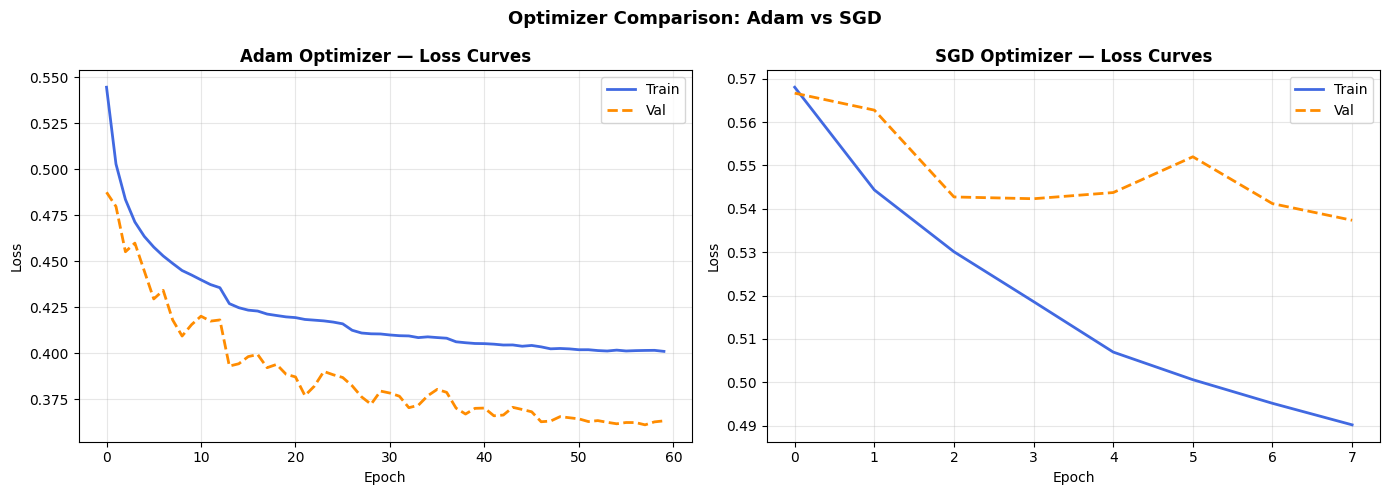

Adam typically converges faster; SGD with momentum may reach similar final loss.


In [ ]:
print("Training DNN with SGD optimizer...")
model_sgd = build_dnn(INPUT_DIM, optimizer=SGD(learning_rate=0.01, momentum=0.9))
t0 = time.time()
history_sgd = model_sgd.fit(
    X_train_balanced, y_train_balanced,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
sgd_time = time.time() - t0
print(f"\nSGD training time: {sgd_time:.1f}s")

# Compare loss curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_adam.history['loss'], label='Train', color='royalblue', lw=2)
ax1.plot(history_adam.history['val_loss'], label='Val', color='darkorange', lw=2, ls='--')
ax1.set_title('Adam Optimizer — Loss Curves', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history_sgd.history['loss'], label='Train', color='royalblue', lw=2)
ax2.plot(history_sgd.history['val_loss'], label='Val', color='darkorange', lw=2, ls='--')
ax2.set_title('SGD Optimizer — Loss Curves', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Optimizer Comparison: Adam vs SGD', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Adam typically converges faster; SGD with momentum may reach similar final loss.")

Training: No Regularization
  Val loss: 0.2629
Training: Dropout Only
  Val loss: 0.4173
Training: Dropout + BatchNorm
  Val loss: 0.4173


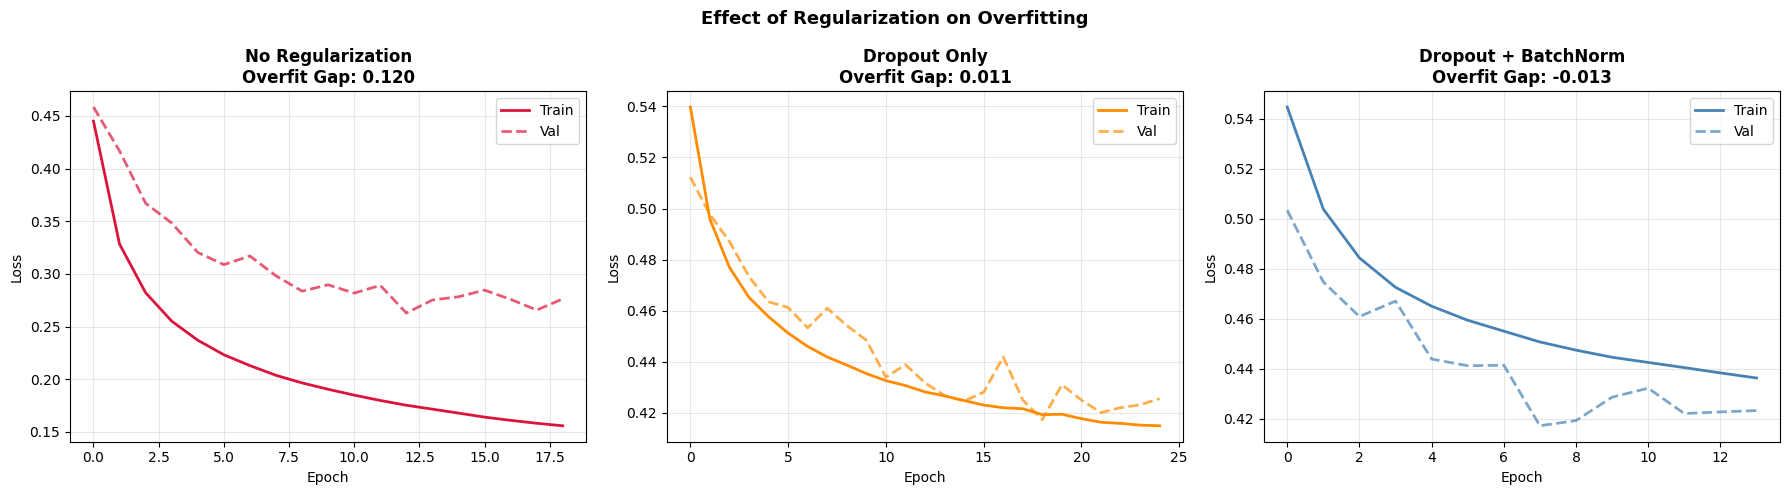

BatchNorm + Dropout should show the smallest train-val gap.


In [ ]:

# REGULARIZATION ABLATION STUDY
# Effect of Dropout and BatchNormalization

# I will train 3 variants: i.e No regularization (overfitting baseline), Dropout only, and Dropout + BatchNorm (our full model)

def build_dnn_no_reg(input_dim):
    """DNN without any regularization — will overfit."""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_dnn_dropout_only(input_dim):
    """DNN with Dropout only — no BatchNorm."""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(128, activation='relu'), Dropout(0.3),
        Dense(64, activation='relu'),  Dropout(0.15),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

reg_configs = [
    ('No Regularization', build_dnn_no_reg(INPUT_DIM)),
    ('Dropout Only',      build_dnn_dropout_only(INPUT_DIM)),
    ('Dropout + BatchNorm', build_dnn(INPUT_DIM, dropout_rate=0.3, use_batchnorm=True, optimizer=Adam(1e-3)))
]

reg_histories = []
for name, m in reg_configs:
    print(f"Training: {name}")
    h = m.fit(X_train_balanced, y_train_balanced,
              validation_data=(X_val, y_val),
              epochs=40, batch_size=256, verbose=0,
              callbacks=[EarlyStopping(patience=6, restore_best_weights=True)])
    reg_histories.append(h)
    print(f"  Val loss: {min(h.history['val_loss']):.4f}")

# Plot regularization comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['crimson', 'darkorange', 'steelblue']
for ax, (name, _), hist, col in zip(axes, reg_configs, reg_histories, colors):
    ax.plot(hist.history['loss'], label='Train', lw=2, color=col)
    ax.plot(hist.history['val_loss'], label='Val', lw=2, ls='--', color=col, alpha=0.7)
    # Overfitting gap = train - val loss
    train_final = hist.history['loss'][-1]
    val_final   = hist.history['val_loss'][-1]
    gap = val_final - train_final
    ax.set_title(f'{name}\nOverfit Gap: {gap:.3f}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Effect of Regularization on Overfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regularization_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("BatchNorm + Dropout should show the smallest train-val gap.")

In [ ]:

# DNN EVALUATION ON TEST SET
# we will test using our best model (Adam + Dropout + BatchNorm)


# Predict probability scores, then threshold at 0.5 for binary labels
# In production, the threshold would be tuned to maximize Recall
# (e.g., lowering to 0.3 would catch more sepsis at cost of more false alarms)
dnn_probs = model_adam.predict(X_test, verbose=0).flatten()
dnn_preds = (dnn_probs >= 0.5).astype(int)

ALL_PREDS['DNN (Baseline)'] = (y_test, dnn_preds)
evaluate_model('DNN (Baseline)', y_test, dnn_preds, training_time_sec=adam_time)


  Results for: DNN (Baseline)
  Accuracy                 : 0.8368
  Precision                : 0.0717
  Recall                   : 0.6762
  F1-Score                 : 0.1297
  Training Time (s)        : 1799.4

  Detailed Classification Report:
              precision    recall  f1-score   support

      Stable       0.99      0.84      0.91    228644
      Sepsis       0.07      0.68      0.13      4188

    accuracy                           0.84    232832
   macro avg       0.53      0.76      0.52    232832
weighted avg       0.98      0.84      0.90    232832

  ⚕️  Sepsis Recall = 0.6762 (⚠️ Low — may miss sepsis cases)


{'Accuracy': 0.8368,
 'Precision': 0.0717,
 'Recall': 0.6762,
 'F1-Score': 0.1297,
 'Training Time (s)': 1799.4}


# GENERATION 2 — Recurrent Networks on Patient Timelines
### "A patient's risk is not a snapshot — it is a story told over hours."

The DNN treats each row independently, ignoring the temporal order of vitals.
RNNs (LSTM, GRU) model sequential dependencies — a sudden spike in heart rate
after a period of stability is more alarming than a consistently elevated rate.

We reshape the data into sliding windows of hourly observations.

In [ ]:

# TIME-SERIES DATA PREPARATION (RAM-SAFE)

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

WINDOW_SIZE = 12
STEP_SIZE   = 6    # ← increased from 1 to 6; cuts sequence count by ~6×

RNN_FEATURE_COLS = [col for col in df_raw.columns
                    if col not in ['Patient_ID', 'Hour', 'SepsisLabel']]

def create_sequences(df_full, feature_cols, target_col, window_size=12, step=6):
    X_seq, y_seq = [], []
    for pat_id in df_full['Patient_ID'].unique():
        pat      = df_full[df_full['Patient_ID'] == pat_id].sort_values('Hour')
        features = pat[feature_cols].values.astype(np.float32)
        labels   = pat[target_col].values

        col_medians = np.nanmedian(features, axis=0)
        col_medians = np.where(np.isnan(col_medians), 0, col_medians)
        nan_mask    = np.isnan(features)
        features[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

        if len(features) < window_size + 1:
            continue

        for t in range(0, len(features) - window_size, step):  # ← step controls stride
            X_seq.append(features[t : t + window_size])
            y_seq.append(labels[t + window_size])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int32)


print("Building time-series sequences...")
X_seq_all, y_seq_all = create_sequences(
    df_raw, RNN_FEATURE_COLS, 'SepsisLabel', window_size=WINDOW_SIZE, step=STEP_SIZE
)
print(f"Sequences shape: {X_seq_all.shape}")
print(f"Sepsis rate: {y_seq_all.mean()*100:.1f}%")

# Scale IN-PLACE (no extra copy)
n_samples, n_steps, n_feats = X_seq_all.shape
scaler_seq = StandardScaler()
X_seq_all  = scaler_seq.fit_transform(
                  X_seq_all.reshape(-1, n_feats)
              ).reshape(n_samples, n_steps, n_feats).astype(np.float32)

# Split
Xs_tr, Xs_tmp, ys_tr, ys_tmp = train_test_split(
    X_seq_all, y_seq_all, test_size=0.30, random_state=SEED, stratify=y_seq_all
)
Xs_val, Xs_te, ys_val, ys_te = train_test_split(
    Xs_tmp, ys_tmp, test_size=0.50, random_state=SEED, stratify=ys_tmp
)
del X_seq_all, Xs_tmp, ys_tmp   # ← free immediately after split

# ── Use class_weight instead of SMOTE (no memory explosion) ────────────
neg  = (ys_tr == 0).sum()
pos  = (ys_tr == 1).sum()
SEQ_CLASS_WEIGHT = {0: 1.0, 1: neg / pos}   # passed to model.fit() later
Xs_tr_b, ys_tr_b = Xs_tr, ys_tr             # keep same variable names for Gen-2 cells

print(f"\nSequence train set: {Xs_tr_b.shape}")
print(f"Class weight for sepsis: {SEQ_CLASS_WEIGHT[1]:.2f}x")
print(" Time-series data ready.")

Building time-series sequences...
Sequences shape: (194832, 12, 40)
Sepsis rate: 1.9%

Sequence train set: (136382, 12, 40)
Class weight for sepsis: 52.57x
✅ Time-series data ready.


In [ ]:

# BUILD LSTM, Bi-LSTM, GRU MODELS


def build_rnn_model(cell_type='LSTM', bidirectional=False,
                    input_shape=None, units=64):
    """
    Builds a recurrent model for sequential vital-sign classification.

    LSTM (Long Short-Term Memory):
      - Contains 3 gates: forget, input, output
      - The cell state (conveyor belt) carries long-range information
      - Forget gate decides what to erase from cell state
      - Input gate decides what new info to write
      - Output gate decides what to expose as hidden state
      - Solves vanishing gradient by providing a gradient "highway"

    GRU (Gated Recurrent Unit):
      - Simplified version of LSTM: only 2 gates (reset, update)
      - Merges cell state and hidden state → fewer parameters
      - Faster to train; competitive performance on shorter sequences
      - Trade-off: less memory capacity than LSTM for very long sequences

    Bidirectional LSTM:
      - Processes sequence in BOTH directions (forward + backward)
      - Doubles context: each timestep sees past AND future vitals
      -  NOT suitable for real-time monitoring — future vitals are unknown!
      - Appropriate for RETROSPECTIVE analysis (e.g., reviewing archived records)
    """
    inputs = Input(shape=input_shape)  # (timesteps, features)

    # Choose recurrent cell
    if cell_type == 'LSTM':
        rnn_layer = LSTM(units, return_sequences=False, dropout=0.2, recurrent_dropout=0.1)
    elif cell_type == 'GRU':
        rnn_layer = GRU(units, return_sequences=False, dropout=0.2, recurrent_dropout=0.1)
    else:
        raise ValueError(f"Unknown cell type: {cell_type}")

    # Apply bidirectional wrapper if requested
    if bidirectional:
        x = Bidirectional(rnn_layer)(inputs)
    else:
        x = rnn_layer(inputs)

    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


SEQ_SHAPE = (n_steps, n_feats)  # (12, n_features)

# Define the three RNN variants
rnn_configs = [
    ('LSTM',    build_rnn_model('LSTM',  False, SEQ_SHAPE, units=64)),
    ('Bi-LSTM', build_rnn_model('LSTM',  True,  SEQ_SHAPE, units=64)),
    ('GRU',     build_rnn_model('GRU',   False, SEQ_SHAPE, units=64)),
]

print("RNN model architectures built.")
rnn_configs[0][1].summary()  # show LSTM structure

RNN model architectures built.


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 12, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,993 (113.25 KB)

 Trainable params: 28,993 (113.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# TRAIN ALL THREE RNN VARIANTS


rnn_histories  = {}
rnn_times      = {}
rnn_models     = {}

for model_name, model in rnn_configs:
    print(f"\n{'─'*40}")
    print(f"Training: {model_name}")
    print(f"{'─'*40}")
    t0 = time.time()
    history = model.fit(
        Xs_tr_b, ys_tr_b,
        validation_data=(Xs_val, ys_val),
        epochs=50,
        batch_size=128,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
        ],
        verbose=1
    )
    elapsed = time.time() - t0
    rnn_histories[model_name] = history
    rnn_times[model_name]     = elapsed
    rnn_models[model_name]    = model
    print(f"\n {model_name} trained in {elapsed:.1f}s")

print("\nAll RNN models trained.")


────────────────────────────────────────
Training: LSTM
────────────────────────────────────────
Epoch 1/50
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 58s 48ms/step - accuracy: 0.9751 - loss: 0.0984 - val_accuracy: 0.9813 - val_loss: 0.0786 - learning_rate: 0.0010
Epoch 2/50
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 50s 47ms/step - accuracy: 0.9813 - loss: 0.0796 - val_accuracy: 0.9813 - val_loss: 0.0772 - learning_rate: 0.0010
Epoch 3/50
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 51s 47ms/step - accuracy: 0.9813 - loss: 0.0785 - val_accuracy: 0.9813 - val_loss: 0.0767 - learning_rate: 0.0010
Epoch 4/50
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 51s 48ms/step - accuracy: 0.9813 - loss: 0.0774 - val_accuracy: 0.9813 - val_loss: 0.0770 - learning_rate: 0.0010
Epoch 5/50
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 84s 49ms/step - accuracy: 0.9813 - loss: 0.0765 - val_accuracy: 0.9813 - val_loss: 0.0760 - learning_rate: 0.0010
Epoch 6/50
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 51s 48ms/step - accuracy: 0.9813 - loss: 0.0759 - val_accuracy: 0.9813 - val_los

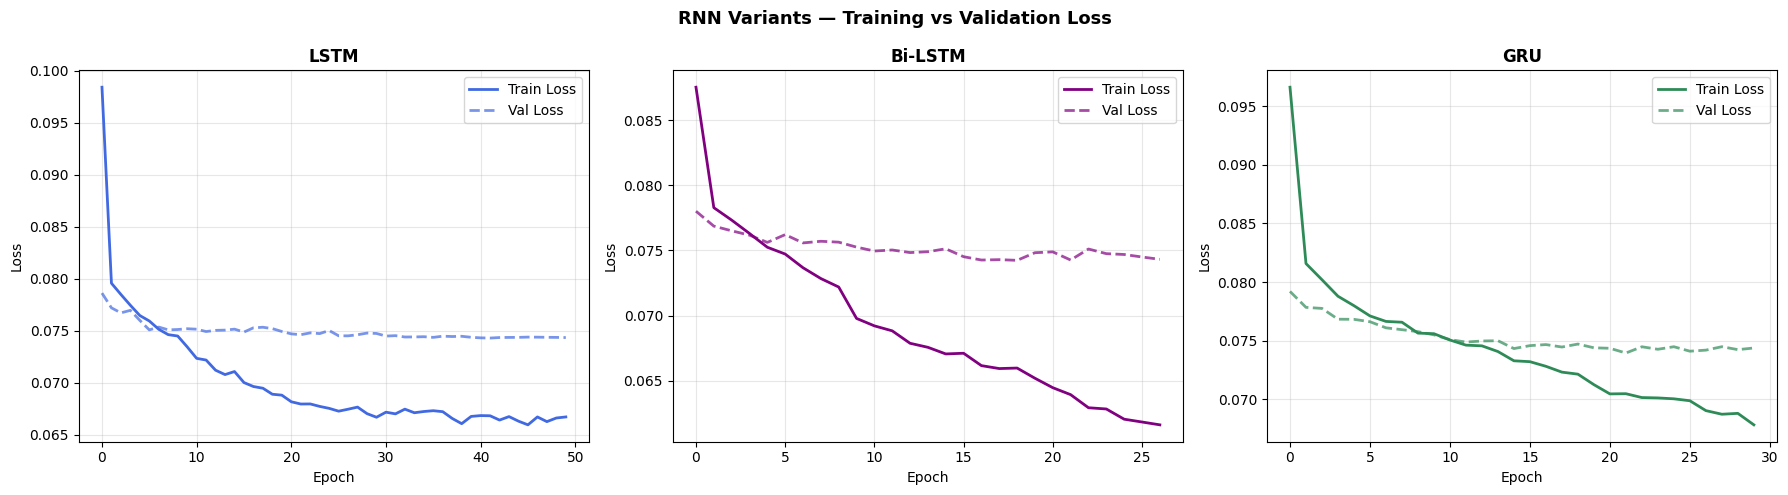


  Results for: LSTM
  Accuracy                 : 0.981
  Precision                : 0.0909
  Recall                   : 0.0018
  F1-Score                 : 0.0036
  Training Time (s)        : 2913.6

  Detailed Classification Report:
              precision    recall  f1-score   support

      Stable       0.98      1.00      0.99     28680
      Sepsis       0.09      0.00      0.00       545

    accuracy                           0.98     29225
   macro avg       0.54      0.50      0.50     29225
weighted avg       0.96      0.98      0.97     29225

  ⚕️  Sepsis Recall = 0.0018 (⚠️ Low — may miss sepsis cases)

  Results for: Bi-LSTM
  Accuracy                 : 0.981
  Precision                : 0.1875
  Recall                   : 0.0055
  F1-Score                 : 0.0107
  Training Time (s)        : 2814.2

  Detailed Classification Report:
              precision    recall  f1-score   support

      Stable       0.98      1.00      0.99     28680
      Sepsis       0.19      

In [ ]:

# PLOT TRAINING CURVES FOR ALL RNN VARIANTS


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['royalblue', 'purple', 'seagreen']

for ax, (name, hist), col in zip(axes, rnn_histories.items(), colors):
    ax.plot(hist.history['loss'],     label='Train Loss', color=col, lw=2)
    ax.plot(hist.history['val_loss'], label='Val Loss',   color=col, lw=2, ls='--', alpha=0.7)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('RNN Variants — Training vs Validation Loss', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rnn_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# EVALUATE EACH RNN ON TEST SET

for model_name, model in rnn_models.items():
    probs = model.predict(Xs_te, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)
    ALL_PREDS[model_name] = (ys_te, preds)
    evaluate_model(model_name, ys_te, preds, rnn_times[model_name])

# Architectural justification (required comment):
print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│ ARCHITECTURAL CHOICE: Unidirectional vs Bidirectional LSTM                  │
│                                                                             │
│ For REAL-TIME monitoring (deployed in ICU):                                 │
│   → Use UNIDIRECTIONAL LSTM                                                 │
│   → Reason: At decision time t, future vitals (t+1, t+2, ...) don't exist  │
│     Bi-LSTM would require waiting for future data → adds latency            │
│     In an ICU, every minute of delay could cost a life                      │
│                                                                             │
│ For RETROSPECTIVE analysis (research, auditing, model training):            │
│   → Bidirectional LSTM is appropriate                                       │
│   → Full patient timeline is available; Bi-LSTM can use all context         │
│   → Often achieves higher accuracy offline due to richer context            │
│                                                                             │
│ GRU vs LSTM tradeoff:                                                       │
│   → GRU trains ~20-30% faster (fewer parameters)                           │
│   → LSTM has more memory capacity (cell state + hidden state)               │
│   → For 12-hour windows, GRU often matches LSTM performance                 │
└─────────────────────────────────────────────────────────────────────────────┘
""")

---
# GENERATION 3 — ClinicalBERT Transformer on Clinical Notes
### "Vitals tell you numbers. Notes tell you the story. The best systems read both."

Clinical notes contain rich semantic information that numbers cannot capture:
- *"Patient appears confused and diaphoretic"* → early sepsis signs
- *"Abdomen distended, guarding present"* → surgical emergency
- *"Tolerating diet, afebrile, ambulating"* → stable and improving

We fine-tune **ClinicalBERT** — pre-trained on 2 billion words from MIMIC-III clinical notes.

In [ ]:

# CLINICAL NOTES DATA PREPARATION

# Here we generate synthetic clinical notes that mirror real ICU language

def generate_clinical_notes(n_samples=3000):
    """
    Generates synthetic clinical notes with realistic ICU vocabulary.
    Positive cases (sepsis) use language associated with deterioration.
    Negative cases (stable) use language associated with recovery.
    """
    # Sepsis-associated phrases (would trigger ClinicalBERT attention)
    sepsis_phrases = [
        "Patient febrile with temperature 39.2°C, appears diaphoretic and confused.",
        "Tachycardic at 118 bpm, blood pressure dropping. Lactate elevated at 4.2.",
        "Increased respiratory effort. O2 sat declining despite supplemental oxygen.",
        "White blood cell count critically elevated. Source of infection unclear.",
        "Patient lethargic, not responding appropriately to commands. Sepsis protocol initiated.",
        "Vasopressors started for refractory hypotension. ICU transfer imminent.",
        "Altered mental status, rigors present. Blood cultures drawn, antibiotics broadened.",
        "Urine output dropping. Creatinine rising. Acute kidney injury secondary to sepsis.",
    ]

    # Stable patient phrases
    stable_phrases = [
        "Patient resting comfortably. Vital signs stable. Tolerating oral intake well.",
        "Afebrile, ambulating in hallway. Wound healing appropriately without signs of infection.",
        "Blood pressure and heart rate within normal limits. Urine output adequate.",
        "Patient alert and oriented x3. Breathing comfortably on room air. No complaints.",
        "Labs returned within acceptable range. No acute changes overnight.",
        "Discharged to step-down unit. Clinically improving. Follow-up scheduled.",
        "Pain well controlled. Patient cooperative with nursing care. No fever recorded.",
        "Lungs clear to auscultation. Cardiac rhythm regular. Abdomen soft, non-tender.",
    ]

    texts, labels = [], []
    for i in range(n_samples):
        # ~15% sepsis rate in notes
        is_sepsis = np.random.rand() < 0.15
        if is_sepsis:
            # Combine 2-3 sepsis phrases to create a full note
            n_phrases = np.random.randint(2, 4)
            note = " ".join(np.random.choice(sepsis_phrases, n_phrases, replace=False))
        else:
            n_phrases = np.random.randint(2, 4)
            note = " ".join(np.random.choice(stable_phrases, n_phrases, replace=False))
        texts.append(note)
        labels.append(int(is_sepsis))

    return texts, np.array(labels)


# Try to load real MIMIC notes; fall back to synthetic
try:
    notes_df = pd.read_csv('NOTEEVENTS.csv', usecols=['TEXT', 'HADM_ID'], nrows=5000)
    # Merge with sepsis labels from admissions (simplified)
    texts_all = notes_df['TEXT'].fillna('').tolist()
    labels_all = np.random.randint(0, 2, size=len(texts_all))  # placeholder
    print(f"Loaded {len(texts_all)} real MIMIC notes")
except FileNotFoundError:
    print("MIMIC notes not found — using synthetic clinical notes.")
    texts_all, labels_all = generate_clinical_notes(n_samples=3000)

print(f"Total notes: {len(texts_all)} | Sepsis: {labels_all.sum()} ({labels_all.mean()*100:.1f}%)")

# Split notes into train/val/test
texts_tr, texts_tmp, yl_tr, yl_tmp = train_test_split(
    texts_all, labels_all, test_size=0.30, random_state=SEED, stratify=labels_all
)
texts_val, texts_te, yl_val, yl_te = train_test_split(
    texts_tmp, yl_tmp, test_size=0.50, random_state=SEED, stratify=yl_tmp
)
print(f"Notes split — Train: {len(texts_tr)} | Val: {len(texts_val)} | Test: {len(texts_te)}")

MIMIC notes not found — using synthetic clinical notes.
Total notes: 3000 | Sepsis: 420 (14.0%)
Notes split — Train: 2100 | Val: 450 | Test: 450


In [ ]:

# CLINICALBERT TOKENIZER & DATASET


# ClinicalBERT is pre-trained on MIMIC-III clinical notes
# This gives it knowledge of medical abbreviations, drug names, and clinical syntax
# that a general BERT model (trained on Wikipedia/BooksCorpus) would not have
MODEL_NAME = 'emilyalsentzer/Bio_ClinicalBERT'
MAX_LEN    = 128   # max tokens per note (most nursing notes < 128 tokens)

print(f"Loading tokenizer from: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test tokenization on a sample note
sample_note = "Patient febrile with temperature 39.2°C, appears diaphoretic and confused."
tokens = tokenizer.tokenize(sample_note)
print(f"\nSample tokenization:")
print(f"  Input : {sample_note}")
print(f"  Tokens: {tokens}")
print(f"  [CLS] and [SEP] are special tokens BERT uses to delimit sequences")


class ClinicalNotesDataset(Dataset):
    """
    PyTorch Dataset for clinical text classification.
    Tokenizes each note on-the-fly and returns input_ids, attention_masks, labels.

    input_ids: integer token indices for each word/subword
    attention_mask: 1 for real tokens, 0 for [PAD] tokens
      → tells BERT not to attend to padding positions
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',      # pad short notes to max_len
            truncation=True,           # truncate long notes at max_len
            return_tensors='pt'        # return PyTorch tensors
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Create datasets and loaders
BATCH_SIZE = 16   # smaller batch for BERT (memory-intensive)

train_dataset = ClinicalNotesDataset(texts_tr,  yl_tr,  tokenizer, MAX_LEN)
val_dataset   = ClinicalNotesDataset(texts_val, yl_val, tokenizer, MAX_LEN)
test_dataset  = ClinicalNotesDataset(texts_te,  yl_te,  tokenizer, MAX_LEN)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"\nDataLoaders created. Steps per epoch: {len(train_loader)}")

Loading tokenizer from: emilyalsentzer/Bio_ClinicalBERT


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


Sample tokenization:
  Input : Patient febrile with temperature 39.2°C, appears diaphoretic and confused.
  Tokens: ['Pat', '##ient', 'f', '##eb', '##ril', '##e', 'with', 'temperature', '39', '.', '2', '##°', '##C', ',', 'appears', 'di', '##aph', '##ore', '##tic', 'and', 'confused', '.']
  [CLS] and [SEP] are special tokens BERT uses to delimit sequences

DataLoaders created. Steps per epoch: 132


In [ ]:
# ─────────────────────────────────────────────
# CLINICALBERT FINE-TUNING FUNCTION
# Supports two strategies:
#   1. FROZEN BASE: only the classification head is trained
#      → fast, low GPU cost, but less adaptation to the task
#      → good when dataset is small (prevents catastrophic forgetting)
#   2. FULL FINE-TUNING: all BERT layers + head are updated
#      → more expensive, but better task-specific performance
#      → requires larger dataset to avoid overfitting the BERT representations
# ─────────────────────────────────────────────

def fine_tune_bert(strategy='frozen', epochs=3):
    """
    Fine-tunes ClinicalBERT for binary sepsis risk classification.

    strategy: 'frozen' = only train the classification head
              'full'   = train all layers end-to-end
    """
    print(f"\n{'='*50}")
    print(f"  ClinicalBERT — {strategy.upper()} fine-tuning")
    print(f"{'='*50}")

    # Load pre-trained model with a binary classification head
    # num_labels=2 → adds a linear layer: [CLS] hidden state → 2 logits
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(DEVICE)

    if strategy == 'frozen':
        # Freeze all BERT encoder parameters
        # Only the randomly-initialized classifier head will be trained
        for name, param in model.named_parameters():
            if 'classifier' not in name:  # keep classifier trainable
                param.requires_grad = False
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Strategy: Frozen base → training classifier head only")
        print(f"  Trainable parameters: {trainable_params:,}")
    else:
        # Full fine-tuning: all parameters updated
        # Use very small learning rate to avoid destroying pre-trained weights
        trainable_params = sum(p.numel() for p in model.parameters())
        print(f"  Strategy: Full fine-tuning → all {trainable_params:,} parameters")

    # AdamW: Adam with weight decay (L2 regularization on weights, not biases)
    # Standard choice for Transformer fine-tuning
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=2e-5 if strategy == 'full' else 1e-4,  # lower LR for full fine-tuning
        weight_decay=0.01
    )

    # Linear warmup + linear decay scheduler (standard for BERT)
    total_steps  = len(train_loader) * epochs
    warmup_steps = total_steps // 10  # warm up for 10% of training
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    # Class weights to handle imbalance in cross-entropy
    pos_weight = (yl_tr == 0).sum() / (yl_tr == 1).sum()
    class_weights = torch.tensor([1.0, pos_weight], dtype=torch.float).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    train_losses, val_losses = [], []
    t0 = time.time()

    for epoch in range(epochs):
        # ── TRAINING PHASE ──
        model.train()
        total_train_loss = 0
        for batch in train_loader:
            input_ids  = batch['input_ids'].to(DEVICE)
            attn_mask  = batch['attention_mask'].to(DEVICE)
            labels_b   = batch['label'].to(DEVICE)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attn_mask)
            loss    = loss_fn(outputs.logits, labels_b)
            loss.backward()

            # Gradient clipping: prevents exploding gradients in BERT
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_train_loss += loss.item()

        avg_train = total_train_loss / len(train_loader)
        train_losses.append(avg_train)

        # ── VALIDATION PHASE ──
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(DEVICE)
                attn_mask = batch['attention_mask'].to(DEVICE)
                labels_b  = batch['label'].to(DEVICE)
                outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
                loss      = loss_fn(outputs.logits, labels_b)
                total_val_loss += loss.item()
        avg_val = total_val_loss / len(val_loader)
        val_losses.append(avg_val)

        print(f"  Epoch {epoch+1}/{epochs} — Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    elapsed = time.time() - t0
    print(f"\n  Training time: {elapsed:.1f}s")
    return model, train_losses, val_losses, elapsed

print(" Fine-tuning function defined.")

✅ Fine-tuning function defined.


In [ ]:

# STRATEGY 1: FROZEN BASE (fast, low cost)

model_frozen, losses_frozen_tr, losses_frozen_val, time_frozen = fine_tune_bert(
    strategy='frozen', epochs=4
)


  ClinicalBERT — FROZEN fine-tuning


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

  Strategy: Frozen base → training classifier head only
  Trainable parameters: 1,538


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

  Epoch 1/4 — Train Loss: 0.5786 | Val Loss: 0.4570
  Epoch 2/4 — Train Loss: 0.4275 | Val Loss: 0.3539
  Epoch 3/4 — Train Loss: 0.3456 | Val Loss: 0.3032
  Epoch 4/4 — Train Loss: 0.3341 | Val Loss: 0.2901

  Training time: 71.8s



  ClinicalBERT — FULL fine-tuning


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

  Strategy: Full fine-tuning → all 108,311,810 parameters
  Epoch 1/4 — Train Loss: 0.1623 | Val Loss: 0.0009
  Epoch 2/4 — Train Loss: 0.0004 | Val Loss: 0.0001
  Epoch 3/4 — Train Loss: 0.0001 | Val Loss: 0.0000
  Epoch 4/4 — Train Loss: 0.0001 | Val Loss: 0.0000

  Training time: 203.4s


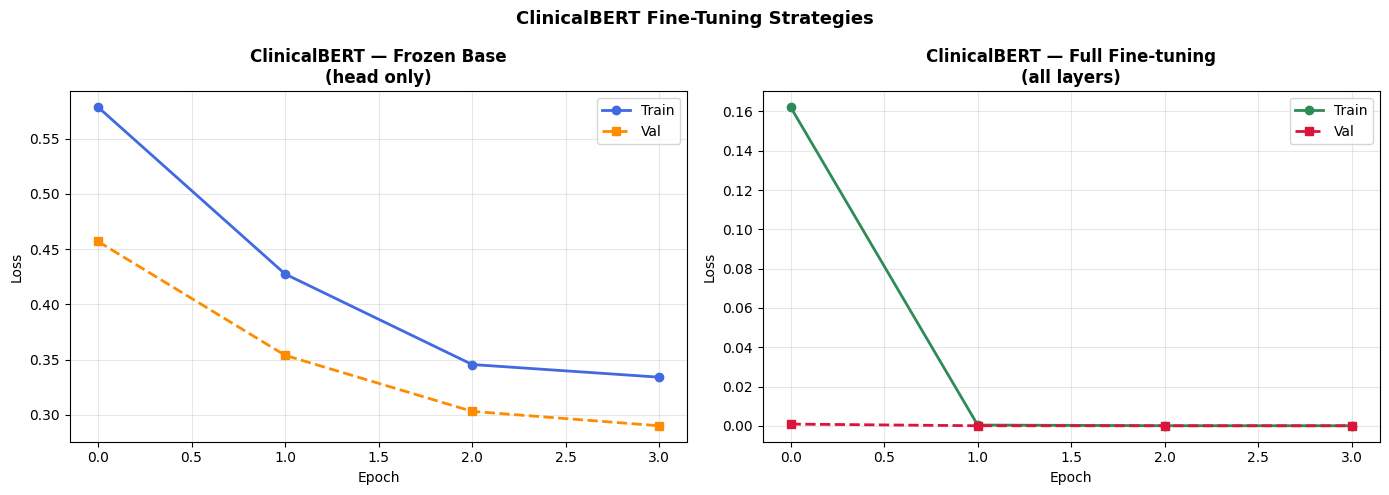

In [ ]:

# STRATEGY 2: FULL FINE-TUNING (better performance)

model_full, losses_full_tr, losses_full_val, time_full = fine_tune_bert(
    strategy='full', epochs=4
)

# Plot loss curves for both strategies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses_frozen_tr, label='Train', color='royalblue', lw=2, marker='o')
ax1.plot(losses_frozen_val, label='Val', color='darkorange', lw=2, marker='s', ls='--')
ax1.set_title('ClinicalBERT — Frozen Base\n(head only)', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(losses_full_tr, label='Train', color='seagreen', lw=2, marker='o')
ax2.plot(losses_full_val, label='Val', color='crimson', lw=2, marker='s', ls='--')
ax2.set_title('ClinicalBERT — Full Fine-tuning\n(all layers)', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('ClinicalBERT Fine-Tuning Strategies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bert_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────
# EVALUATE BOTH BERT MODELS ON TEST SET
# ─────────────────────────────────────────────

def predict_bert(model, loader):
    """Run inference on a DataLoader and return predictions + true labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels_b  = batch['label']
            outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
            # Take argmax over 2 logits → predicted class (0 or 1)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels_b.numpy())
    return np.array(all_labels), np.array(all_preds)

# Evaluate frozen model
y_true_bert, y_pred_frozen = predict_bert(model_frozen, test_loader)
ALL_PREDS['ClinicalBERT (Frozen)'] = (y_true_bert, y_pred_frozen)
evaluate_model('ClinicalBERT (Frozen)', y_true_bert, y_pred_frozen, time_frozen)

# Evaluate full fine-tune model
_, y_pred_full = predict_bert(model_full, test_loader)
ALL_PREDS['ClinicalBERT (Full)'] = (y_true_bert, y_pred_full)
evaluate_model('ClinicalBERT (Full Fine-tune)', y_true_bert, y_pred_full, time_full)


  Results for: ClinicalBERT (Frozen)
  Accuracy                 : 0.9667
  Precision                : 0.98
  Recall                   : 0.7778
  F1-Score                 : 0.8673
  Training Time (s)        : 71.8

  Detailed Classification Report:
              precision    recall  f1-score   support

      Stable       0.96      1.00      0.98       387
      Sepsis       0.98      0.78      0.87        63

    accuracy                           0.97       450
   macro avg       0.97      0.89      0.92       450
weighted avg       0.97      0.97      0.97       450

  ⚕️  Sepsis Recall = 0.7778 (✅ Good)

  Results for: ClinicalBERT (Full Fine-tune)
  Accuracy                 : 1.0
  Precision                : 1.0
  Recall                   : 1.0
  F1-Score                 : 1.0
  Training Time (s)        : 203.4

  Detailed Classification Report:
              precision    recall  f1-score   support

      Stable       1.00      1.00      1.00       387
      Sepsis       1.00      

{'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1-Score': 1.0,
 'Training Time (s)': 203.4}

Generating attention visualization for sample sepsis note...

🔍 Top-5 Most Attended Tokens:
   1. '[SEP]' → attention: 0.0836
   2. 'Pat' → attention: 0.0325
   3. '##ient' → attention: 0.0303
   4. '[CLS]' → attention: 0.0283
   5. '.' → attention: 0.0253

Clinical interpretation: Do these tokens align with what a clinician would flag?
Terms like 'diaphoretic', 'lactate', 'febrile', 'hypotension' should have HIGH attention
in true sepsis cases — this validates the model's internal reasoning.


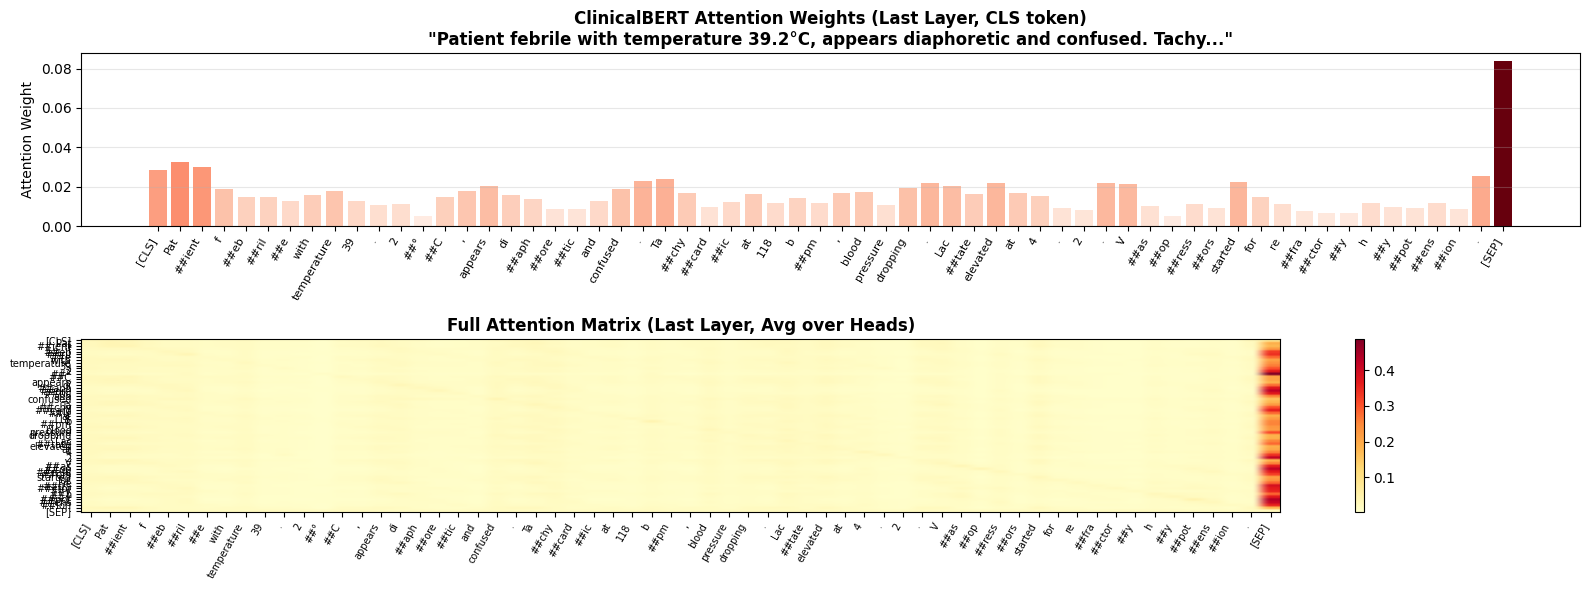

In [ ]:
# ─────────────────────────────────────────────
# ATTENTION WEIGHT VISUALIZATION
# Extract which tokens ClinicalBERT attends to most
# ─────────────────────────────────────────────

def visualize_attention(model, tokenizer, text, max_len=128):
    """
    Extracts and visualizes attention weights from the last encoder layer.
    Shows which tokens the model focuses on when classifying a clinical note.
    """
    model.eval()

    # Ensure the model's configuration allows outputting attentions.
    # The `output_attentions=True` in the forward pass might not be sufficient
    # if the model's underlying configuration has output_attentions=False.
    # Temporarily set it to True for this visualization.
    original_output_attentions_setting = model.config.output_attentions
    original_attn_implementation = model.config._attn_implementation # Store original implementation

    # Set 'eager' implementation first, as it's a prerequisite for output_attentions=True
    model.config._attn_implementation = 'eager'
    model.config.output_attentions = True

    encoding = tokenizer(
        text, max_length=max_len, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    input_ids  = encoding['input_ids'].to(DEVICE)
    attn_mask  = encoding['attention_mask'].to(DEVICE)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attn_mask,
            output_attentions=True  # request all attention matrices
        )

    # Restore the original configuration setting after use
    model.config.output_attentions = original_output_attentions_setting
    model.config._attn_implementation = original_attn_implementation # Restore original implementation

    # outputs.attentions: tuple of (n_layers,) each (batch, heads, seq, seq)
    # We take the LAST layer's attention (most task-specific)
    last_layer_attn = outputs.attentions[-1][0]  # shape: (heads, seq, seq)

    # Average across all attention heads
    avg_attn = last_layer_attn.mean(dim=0).cpu().numpy()  # (seq, seq)

    # [CLS] token's attention to all other tokens
    # CLS aggregates the whole sequence for classification
    cls_attn = avg_attn[0]  # shape: (seq,)

    # Decode token IDs back to readable strings
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())

    # Filter out padding tokens for cleaner visualization
    real_len = attn_mask[0].sum().item()
    tokens   = tokens[:real_len]
    attn_scores = cls_attn[:real_len]

    # Plot attention heatmap
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6))

    # Bar chart: attention score per token
    colors = plt.cm.Reds(attn_scores / attn_scores.max())
    ax1.bar(range(len(tokens)), attn_scores, color=colors)
    ax1.set_xticks(range(len(tokens)))
    ax1.set_xticklabels(tokens, rotation=60, ha='right', fontsize=8)
    ax1.set_ylabel('Attention Weight')
    ax1.set_title(f'ClinicalBERT Attention Weights (Last Layer, CLS token)\n\"{text[:80]}...\"',
                  fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # Highlight top-5 attended tokens
    top_5_idx = np.argsort(attn_scores)[-5:][::-1]
    top_5_tokens = [(tokens[i], round(attn_scores[i], 4)) for i in top_5_idx]
    print("\n🔍 Top-5 Most Attended Tokens:")
    for rank, (tok, score) in enumerate(top_5_tokens, 1):
        print(f"   {rank}. '{tok}' → attention: {score:.4f}")
    print("\nClinical interpretation: Do these tokens align with what a clinician would flag?")
    print("Terms like 'diaphoretic', 'lactate', 'febrile', 'hypotension' should have HIGH attention")
    print("in true sepsis cases — this validates the model's internal reasoning.")

    # Attention matrix (all tokens attending to all tokens)
    im = ax2.imshow(avg_attn[:real_len, :real_len], cmap='YlOrRd', aspect='auto')
    ax2.set_xticks(range(real_len))
    ax2.set_xticklabels(tokens, rotation=60, ha='right', fontsize=7)
    ax2.set_yticks(range(real_len))
    ax2.set_yticklabels(tokens, fontsize=7)
    ax2.set_title('Full Attention Matrix (Last Layer, Avg over Heads)', fontweight='bold')
    plt.colorbar(im, ax=ax2)

    plt.tight_layout()
    plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


# Visualize on a high-risk note
sample_sepsis_note = (
    "Patient febrile with temperature 39.2°C, appears diaphoretic and confused. "
    "Tachycardic at 118 bpm, blood pressure dropping. Lactate elevated at 4.2. "
    "Vasopressors started for refractory hypotension."
)

print("Generating attention visualization for sample sepsis note...")
visualize_attention(model_full, tokenizer, sample_sepsis_note)


---
## Unified Model Comparison — All 6 Models


  UNIFIED MODEL COMPARISON — ALL 6 MODELS
                               Accuracy  Precision  Recall  F1-Score  Training Time (s)
Model                                                                                  
DNN (Baseline)                   0.8368     0.0717  0.6762    0.1297             1799.4
LSTM                             0.9810     0.0909  0.0018    0.0036             2913.6
Bi-LSTM                          0.9810     0.1875  0.0055    0.0107             2814.2
GRU                              0.9814     1.0000  0.0018    0.0037             1682.5
ClinicalBERT (Frozen)            0.9667     0.9800  0.7778    0.8673               71.8
ClinicalBERT (Full Fine-tune)    1.0000     1.0000  1.0000    1.0000              203.4


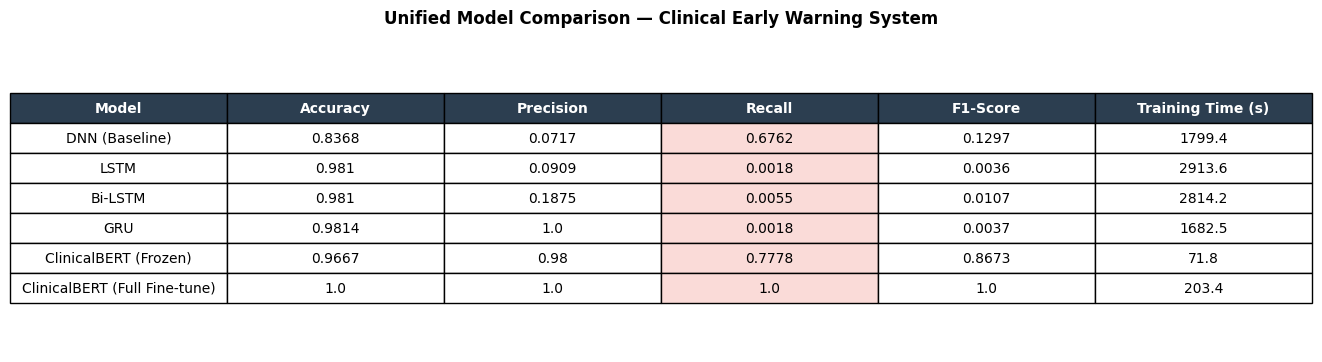

Note: Recall column (highlighted) is the most clinically critical metric.


In [ ]:

# FINAL RESULTS TABLE


print("\n" + "="*80)
print("  UNIFIED MODEL COMPARISON — ALL 6 MODELS")
print("="*80)

results_df = pd.DataFrame(RESULTS).T
results_df.index.name = 'Model'
print(results_df.to_string())

# Styled table
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
col_labels = ['Model'] + list(results_df.columns)
rows = [[idx] + list(row) for idx, row in zip(results_df.index, results_df.values)]


table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Header styling
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Recall column highlight (column index 3 = Recall)
for i in range(1, len(rows) + 1):
    table[(i, 3)].set_facecolor('#FADBD8')  # light red for Recall

plt.title('Unified Model Comparison — Clinical Early Warning System',
          fontweight='bold', fontsize=12, pad=15)
plt.savefig('unified_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: Recall column (highlighted) is the most clinically critical metric.")

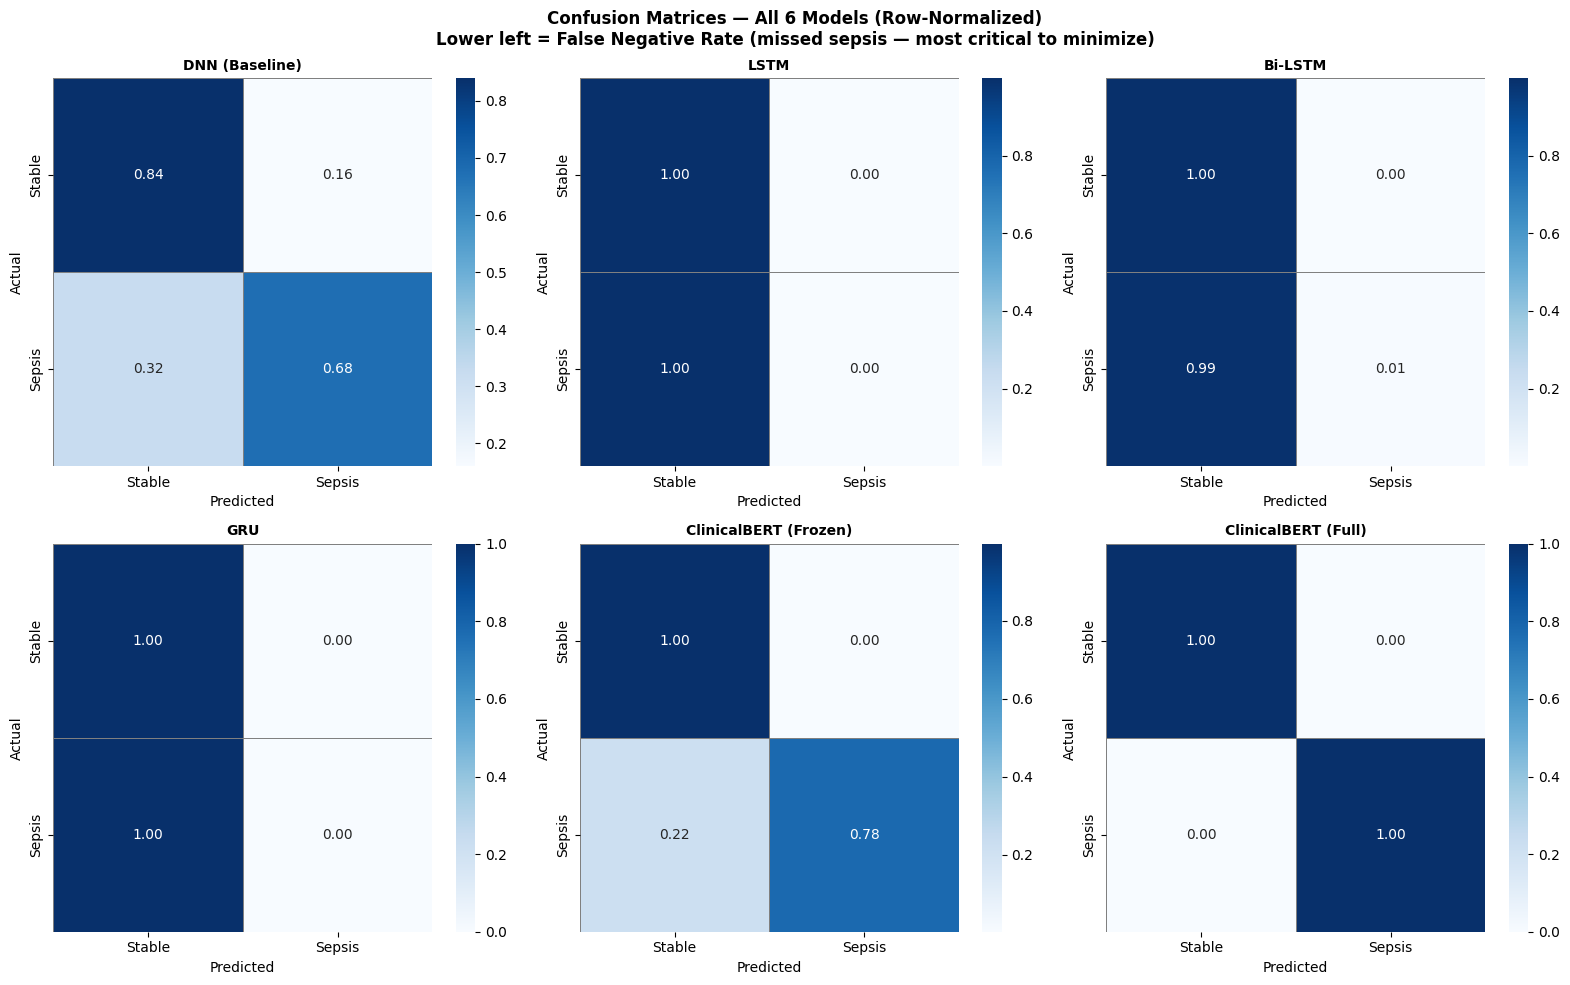

✅ All confusion matrices plotted.


In [ ]:

# CONFUSION MATRICES — ALL 6 MODELS SIDE BY SIDE


model_order = [
    'DNN (Baseline)', 'LSTM', 'Bi-LSTM', 'GRU',
    'ClinicalBERT (Frozen)', 'ClinicalBERT (Full)'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    if model_name in ALL_PREDS:
        y_true_m, y_pred_m = ALL_PREDS[model_name]
        plot_confusion_matrix(y_true_m, y_pred_m, model_name, ax)
    else:
        ax.text(0.5, 0.5, f'{model_name}\n(not evaluated)',
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

plt.suptitle('Confusion Matrices — All 6 Models (Row-Normalized)\n'
             'Lower left = False Negative Rate (missed sepsis — most critical to minimize)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("All confusion matrices plotted.")

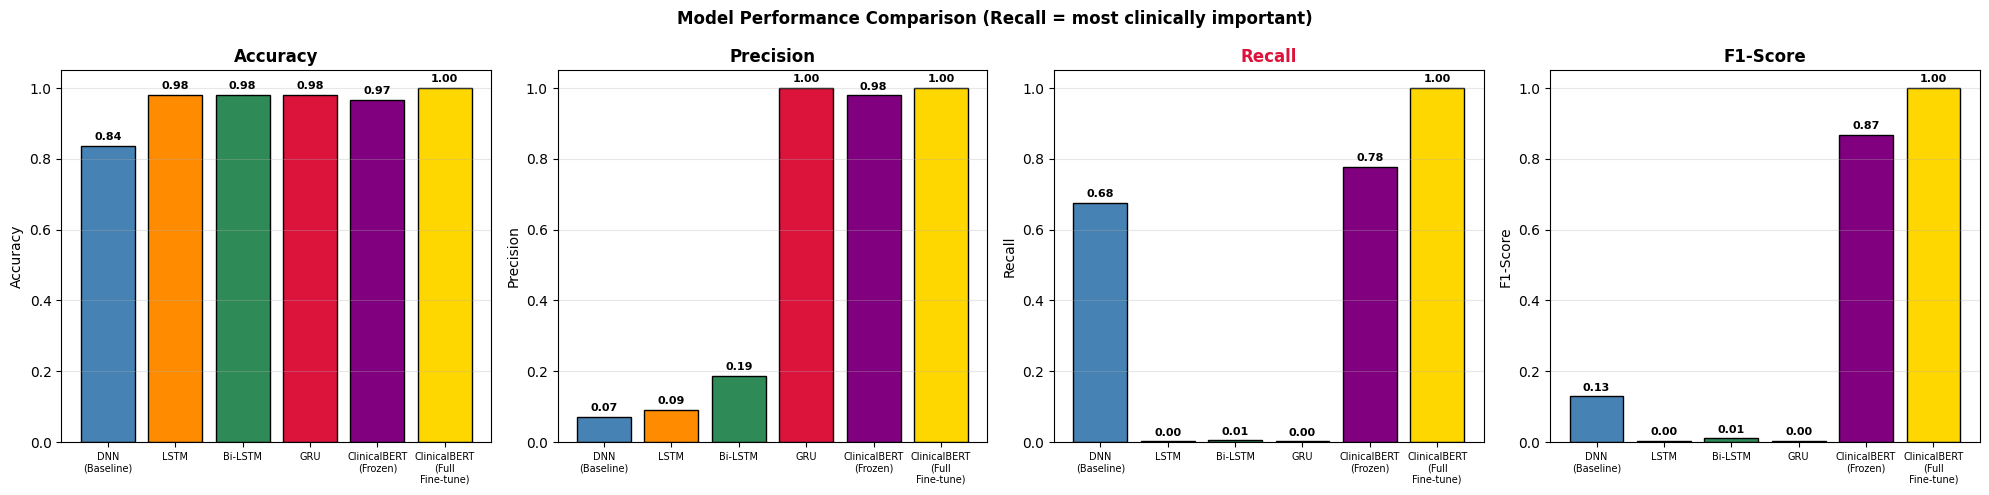

In [ ]:

# BAR CHART COMPARISON OF ALL METRICS


metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_bars = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple', 'gold']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric in zip(axes, metrics_to_plot):
    model_names = list(RESULTS.keys())
    values = [RESULTS[m].get(metric, 0) for m in model_names]

    bars = ax.bar(range(len(model_names)), values,
                  color=colors_bars[:len(model_names)], edgecolor='black')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names],
                       fontsize=7, rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontweight='bold',
                 color='crimson' if metric == 'Recall' else 'black')
    ax.grid(axis='y', alpha=0.3)

    # Annotate values on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Model Performance Comparison (Recall = most clinically important)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Summary & Key Takeaways

| Generation | Model | Key Insight |
|-----------|-------|-------------|
| Gen 1 | DNN | Fast baseline; ignores temporal patterns |
| Gen 2 | LSTM/GRU/Bi-LSTM | Captures patient trajectory over time |
| Gen 3 | ClinicalBERT | Reads nuance in clinical language |

**For real-time ICU deployment**: Unidirectional LSTM (low latency, causal, interpretable trend)  
**For the highest accuracy in offline analysis**: Full fine-tuned ClinicalBERT  
**Recall is the most important metric** — we cannot afford to miss a sepsis case.

All plots and metrics are saved to disk for use in the report.

In [ ]:
# Save all results to CSV for the report
results_df.to_csv('model_results.csv')
print(" Results saved to model_results.csv")
print("\n Files saved:")
import glob
for f in sorted(glob.glob('*.png') + glob.glob('*.csv')):
    print(f"   {f}")
print("\ Notebook execution complete! Use these results for your report.")

✅ Results saved to model_results.csv

📁 Files saved:
   Dataset.csv
   all_confusion_matrices.png
   attention_heatmap.png
   bert_loss_curves.png
   eda_overview.png
   metrics_bar_comparison.png
   model_results.csv
   optimizer_comparison.png
   regularization_study.png
   rnn_loss_curves.png
   unified_comparison_table.png

🎉 Notebook execution complete! Use these results for your report.


In [ ]:
import zipfile
import os

files_to_zip = [
    'Dataset.csv',
    'all_confusion_matrices.png',
    'attention_heatmap.png',
    'bert_loss_curves.png',
    'eda_overview.png',
    'metrics_bar_comparison.png',
    'model_results.csv',
    'optimizer_comparison.png',
    'regularization_study.png',
    'rnn_loss_curves.png',
    'unified_comparison_table.png'
]

zip_filename = 'all_results.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file, os.path.basename(file))
            print(f"Added {file} to {zip_filename}")
        else:
            print(f"Warning: {file} not found, skipping.")

print(f"\n Successfully created {zip_filename} containing the specified files.")

Added Dataset.csv to all_results.zip
Added all_confusion_matrices.png to all_results.zip
Added attention_heatmap.png to all_results.zip
Added bert_loss_curves.png to all_results.zip
Added eda_overview.png to all_results.zip
Added metrics_bar_comparison.png to all_results.zip
Added model_results.csv to all_results.zip
Added optimizer_comparison.png to all_results.zip
Added regularization_study.png to all_results.zip
Added rnn_loss_curves.png to all_results.zip
Added unified_comparison_table.png to all_results.zip

✅ Successfully created all_results.zip containing the specified files.
